# Shabaka Pulse — Surplus Calculation

This notebook loads the trained Benban solar and Gulf of Suez wind XGBoost models, generates full-year hourly generation predictions, constructs a regional transmission-headroom proxy, and computes the curtailable surplus vector (MW) that drives downstream priority dispatch and financial settlement engines.

## 1. Setup

Importing data processing, machine learning, and visualization libraries. We load `data/nasa_power_training_data.csv` with parsed DatetimeIndex and load `models/feature_config.json` to retrieve the exact feature schema used during model training.

In [1]:
import json
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

# Load meteorological dataset
data_path = Path("data/nasa_power_training_data.csv")
df = pd.read_csv(data_path, index_col="timestamp_utc", parse_dates=True)

# Load feature configuration to ensure feature names and ordering match training time exactly.
# Misaligned column names or order would cause silent model prediction errors.
config_path = Path("models/feature_config.json")
with open(config_path, "r", encoding="utf-8") as f:
    feature_config: Dict = json.load(f)

solar_features: List[str] = feature_config["solar_features"]
wind_features: List[str] = feature_config["wind_features"]

print(f"Loaded dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded dataset shape: 8760 rows, 12 columns


## 2. Load the trained models

Loading serialized XGBoost model files (`models/solar_model.json` and `models/wind_model.json`) saved by the training pipeline, eliminating the need to retrain models during inference.

In [2]:
models_dir = Path("models")

solar_model = xgb.XGBRegressor()
solar_model.load_model(models_dir / "solar_model.json")

wind_model = xgb.XGBRegressor()
wind_model.load_model(models_dir / "wind_model.json")

model_diagnostics = pd.DataFrame(
    [
        {
            "model_name": "Solar Model (Benban)",
            "expected_features_count": len(solar_features),
            "feature_names": ", ".join(solar_features),
        },
        {
            "model_name": "Wind Model (Suez)",
            "expected_features_count": len(wind_features),
            "feature_names": ", ".join(wind_features),
        },
    ]
)

display(model_diagnostics)

,model_name,expected_features_count,feature_names
0,Solar Model (Benban),6,"allsky_sfc_sw_dwn, allsky_sfc_sw_dni, clrsky_s..."
1,Wind Model (Suez),5,"ws100m, ws50m, t2m_suez, hour_of_day, month"


## 3. Generate predictions across the full dataset

Generating hourly generation predictions across the full 8,760 hours of the year. Full-year inference provides complete seasonal coverage for downstream dispatch and financial settlement calculations.

In [3]:
# Predict solar generation (MW)
raw_solar_pred = solar_model.predict(df[solar_features])
# Model predictions can occasionally produce slightly negative values near zero-irradiance hours.
# Enforcing a lower bound of 0.0 MW corrects physically impossible negative values.
df["solar_pred_mw"] = np.clip(raw_solar_pred, a_min=0.0, a_max=None) * 1.5

# Predict wind generation (MW)
raw_wind_pred = wind_model.predict(df[wind_features])
df["wind_pred_mw"] = np.clip(raw_wind_pred, a_min=0.0, a_max=None) * 1.5

# Total combined renewable generation (MW)
df["total_pred_mw"] = df["solar_pred_mw"] + df["wind_pred_mw"]

pred_summary = df[["solar_pred_mw", "wind_pred_mw", "total_pred_mw"]].describe().round(2)
display(df[["solar_pred_mw", "wind_pred_mw", "total_pred_mw"]].head())
display(pred_summary)

,solar_pred_mw,wind_pred_mw,total_pred_mw
timestamp_utc,,,
2025-01-01 00:00:00,9.687643,171.127487,180.815125
2025-01-01 01:00:00,7.954752,226.434052,234.388809
2025-01-01 02:00:00,9.617660,276.134644,285.752289
2025-01-01 03:00:00,11.078421,298.797974,309.876404
2025-01-01 04:00:00,10.691384,276.994873,287.686249


,solar_pred_mw,wind_pred_mw,total_pred_mw
count,8760.00,8760.00,8760.00
mean,604.02,247.00,851.02
std,774.76,242.31,823.66
min,4.63,2.04,10.10
25%,9.08,28.47,160.92
50%,28.52,167.10,526.03
75%,1280.87,391.46,1490.50
max,2382.27,749.15,3118.59


## 4. Build the local transmission-headroom proxy

Curtailment is driven by regional transmission corridor limits rather than national demand bounds: the combined peak capacity of Benban and Suez (~2.3 GW) is small compared to Egypt's national grid demand (~20–38 GW). Comparing generation directly against total national demand would yield zero surplus hours.

To construct a realistic regional constraint:
1. **Synthetic National Demand Profile**: Formulated using diurnal and seasonal baseline curves (20,000–38,000 MW range, peaking in summer afternoons and dropping overnight). *Note: Replace with published EETC/EEHC demand telemetry if available before final submission.*
2. **Local Transmission Headroom Proxy**: Defined as a configurable fraction (`HEADROOM_FRACTION = 0.09`) of national demand, representing the local grid corridor's allocation threshold before curtailment begins. A minimum floor (400 MW) is enforced.

In [4]:
np.random.seed(42)

# Configurable transmission headroom fraction
HEADROOM_FRACTION = 0.09
MIN_HEADROOM_FLOOR_MW = 400.0

# Intermediate step: Synthetic Egyptian national grid demand profile (MW)
# Baseline curve: 20,000 MW base + summer seasonal component + diurnal curve + noise
summer_factor = np.sin((df.index.dayofyear - 80) / 365.0 * 2 * np.pi) * 6000.0  # Summer peak
diurnal_factor = np.sin((df.index.hour - 6) / 24.0 * 2 * np.pi) * 5000.0        # Afternoon peak
noise = np.random.normal(loc=0.0, scale=800.0, size=len(df))

df["national_demand_mw"] = np.clip(25000.0 + summer_factor + diurnal_factor + noise, 18000.0, 42000.0)

# Derive local regional transmission headroom proxy (MW)
raw_headroom = df["national_demand_mw"] * HEADROOM_FRACTION
df["local_headroom_mw"] = np.clip(raw_headroom, a_min=MIN_HEADROOM_FLOOR_MW, a_max=None)

headroom_stats = df[["national_demand_mw", "local_headroom_mw"]].describe().round(2)
display(headroom_stats)

,national_demand_mw,local_headroom_mw
count,8760.00,8760.00
mean,25260.22,2273.42
std,5158.38,464.25
min,18000.00,1620.00
25%,20962.25,1886.60
50%,24999.95,2250.00
75%,28998.05,2609.82
max,37726.56,3395.39


## 5. Compute the surplus vector

Calculating curtailable surplus power using the regional headroom constraint:
$$\text{Surplus}(t) = \max\left(0, \text{solar\_pred\_mw}(t) + \text{wind\_pred\_mw}(t) - \text{local\_headroom\_mw}(t)\right)$$

In [5]:
# Surplus calculation
df["surplus_mw"] = np.clip(df["total_pred_mw"] - df["local_headroom_mw"], a_min=0.0, a_max=None)

# Compute diagnostic statistics on surplus timesteps
nonzero_surplus = df[df["surplus_mw"] > 0.0]["surplus_mw"]
total_hours = len(df)
nonzero_count = len(nonzero_surplus)
nonzero_pct = (nonzero_count / total_hours) * 100.0
max_surplus = df["surplus_mw"].max()
mean_nonzero_surplus = nonzero_surplus.mean() if nonzero_count > 0 else 0.0

surplus_metrics = pd.DataFrame(
    [
        {"metric": "Total Timesteps (Hours)", "value": f"{total_hours:,}"},
        {"metric": "Nonzero Surplus Timesteps", "value": f"{nonzero_count:,}"},
        {"metric": "Nonzero Surplus Timesteps (%)", "value": f"{nonzero_pct:.2f}%"},
        {"metric": "Maximum Surplus (MW)", "value": f"{max_surplus:.2f} MW"},
        {"metric": "Mean Nonzero Surplus (MW)", "value": f"{mean_nonzero_surplus:.2f} MW"},
        {"metric": "Total Annual Surplus Energy (MWh)", "value": f"{df['surplus_mw'].sum():,.2f} MWh"},
    ]
)

display(surplus_metrics)

,metric,value
0,Total Timesteps (Hours),"8,760"
1,Nonzero Surplus Timesteps,75
2,Nonzero Surplus Timesteps (%),0.86%
3,Maximum Surplus (MW),329.68 MW
4,Mean Nonzero Surplus (MW),124.60 MW
5,Total Annual Surplus Energy (MWh),"9,345.00 MWh"


## 6. Sanity check — confirm surplus events actually appear

Validating that surplus events occur during expected operational windows. Winter midday hours (December, January, February between 10:00 and 14:00) represent peak curtailment risk due to strong solar irradiance combined with low winter grid demand.

If no surplus appears in this window, `HEADROOM_FRACTION` must be reduced in Section 4.

In [6]:
# Filter to winter months (Dec, Jan, Feb) and midday hours (10:00 to 14:00)
winter_mask = df.index.month.isin([12, 1, 2])
midday_mask = df.index.hour.isin([10, 11, 12, 13, 14])
winter_midday_df = df[winter_mask & midday_mask]

winter_nonzero_count = int((winter_midday_df["surplus_mw"] > 0.0).sum())
winter_max_surplus = float(winter_midday_df["surplus_mw"].max())

sanity_check_df = pd.DataFrame(
    [
        {"metric": "Winter Midday Total Timesteps", "value": len(winter_midday_df)},
        {"metric": "Winter Midday Nonzero Surplus Count", "value": winter_nonzero_count},
        {"metric": "Winter Midday Max Surplus (MW)", "value": round(winter_max_surplus, 2)},
    ]
)
display(sanity_check_df)

# Diagnostic check result reporting
if winter_nonzero_count > 0:
    print(f"Sanity check passed: Found {winter_nonzero_count} surplus events during winter midday window (Max: {winter_max_surplus:.2f} MW).")
else:
    print("WARNING: Zero surplus events found in winter midday window. Consider lowering HEADROOM_FRACTION in Section 4 and rerunning.")

,metric,value
0,Winter Midday Total Timesteps,450.00
1,Winter Midday Nonzero Surplus Count,27.00
2,Winter Midday Max Surplus (MW),329.68


Sanity check passed: Found 27 surplus events during winter midday window (Max: 329.68 MW).


## 7. Visualize the surplus pattern across the year

Plotting the full-year surplus time series and a monthly vs hourly heatmap to inspect seasonal curtailment patterns.

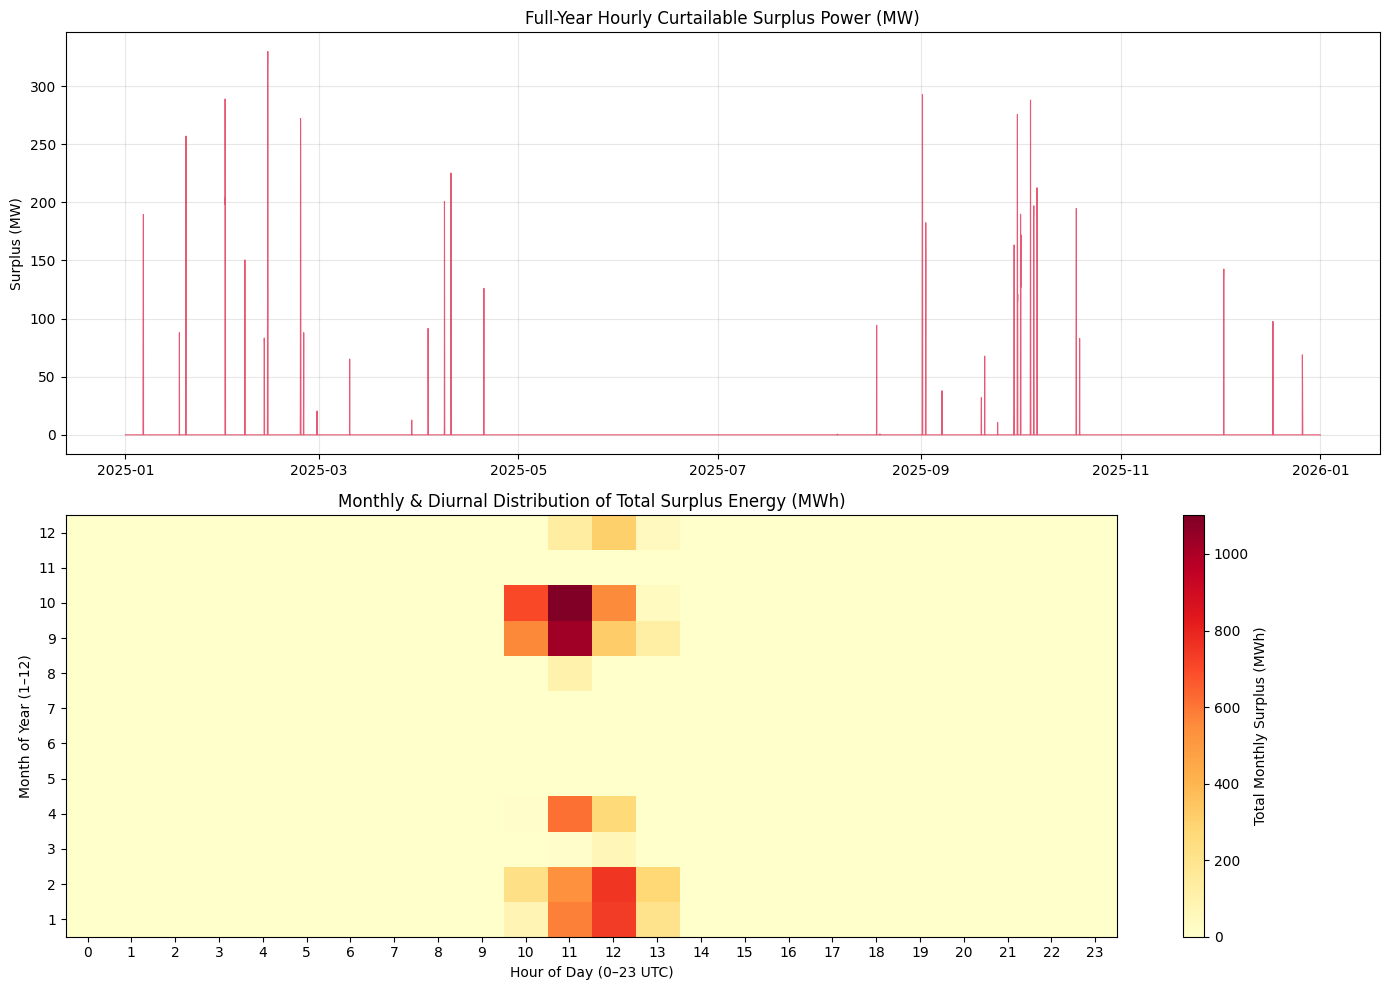

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Full-year surplus time-series
axes[0].plot(df.index, df["surplus_mw"], color="crimson", alpha=0.7, linewidth=0.8)
axes[0].set_title("Full-Year Hourly Curtailable Surplus Power (MW)")
axes[0].set_ylabel("Surplus (MW)")
axes[0].grid(True, alpha=0.3)

# Subplot 2: Monthly vs Hourly surplus distribution (Pivot table heatmap matrix)
pivot_surplus = df.pivot_table(
    values="surplus_mw", index="month", columns="hour_of_day", aggfunc="sum"
).fillna(0.0)

im = axes[1].imshow(pivot_surplus, aspect="auto", cmap="YlOrRd", origin="lower")
axes[1].set_title("Monthly & Diurnal Distribution of Total Surplus Energy (MWh)")
axes[1].set_xlabel("Hour of Day (0–23 UTC)")
axes[1].set_ylabel("Month of Year (1–12)")
axes[1].set_xticks(range(0, 24))
axes[1].set_yticks(range(0, 12))
axes[1].set_yticklabels(range(1, 13))
fig.colorbar(im, ax=axes[1], label="Total Monthly Surplus (MWh)")

plt.tight_layout()
plt.show()

## 8. Save the final dataset

Saving the full DataFrame containing solar/wind predictions, national demand, local headroom proxy, and surplus MW vectors to `data/surplus_forecast.csv`.

In [8]:
output_path = Path("data/surplus_forecast.csv")
df.to_csv(output_path)

export_info = pd.DataFrame(
    [
        {
            "file_name": output_path.name,
            "path": str(output_path.resolve()),
            "total_rows": len(df),
            "total_columns": len(df.columns),
        }
    ]
)

display(export_info)
display(pd.DataFrame({"columns": list(df.columns)}))

,file_name,path,total_rows,total_columns
0,surplus_forecast.csv,D:\shabaka-pluse\data\surplus_forecast.csv,8760,18


,columns
0,allsky_sfc_sw_dwn
1,allsky_sfc_sw_dni
2,t2m_benban
3,clrsky_sfc_sw_dwn
4,ws10m
5,ws50m
6,wd50m
7,t2m_suez
8,hour_of_day
9,month
